#Imports and data loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.utils.class_weight import compute_class_weight
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, TensorDataset, random_split
import copy
from collections import Counter
import os
from glob import glob
from PIL import Image
import random
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re
import string
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer

pd.set_option('display.max_columns', None)  # None means no limit

# Set option to display the full width of each column
pd.set_option('display.width', None)


# full dataset view
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

import plotly.offline as py
from plotly.offline import iplot, init_notebook_mode, plot
import plotly.graph_objs as go
init_notebook_mode(connected = True) # Required to use plotly offline in jupyter notebook

from IPython.display import Markdown
def bold(string):
    display(Markdown(string))

#1. Preparation and analysis of chosen data

#About dataset

https://www.kaggle.com/datasets/saranyaponnarasu/bank-marketing-term-deposits-classification/data

The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y)

The data is related with direct marketing campaigns of a Portuguese banking institution. The marketing campaigns were based on phone calls. Often, more than one contact to the same client was required, in order to access if the product (bank term deposit) would be ('yes') or not ('no') subscribed

In [ ]:
''' Read in the whole dataset '''
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/train_deposit.csv");
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/test_deposit.csv");

# df = pd.concat([df_train, df_test], sort=False)

In [ ]:
# df.head()
df_train.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:
df_test.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [ ]:
df_train.dtypes.value_counts()

,count
object,10
int64,7


In [ ]:
df_test.dtypes.value_counts()

,count
object,10
int64,7


In [ ]:
df_train.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [ ]:
df_test.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


In [ ]:
df_train.shape

(45211, 17)

In [ ]:
df_test.shape

(4521, 17)

In [ ]:
df_train['y'].unique(), df_test['y'].unique()

(array(['no', 'yes'], dtype=object), array(['no', 'yes'], dtype=object))

In [ ]:
df_train.job.unique(), df_test.job.unique()

(array(['management', 'technician', 'entrepreneur', 'blue-collar',
        'unknown', 'retired', 'admin.', 'services', 'self-employed',
        'unemployed', 'housemaid', 'student'], dtype=object),
 array(['unemployed', 'services', 'management', 'blue-collar',
        'self-employed', 'technician', 'entrepreneur', 'admin.', 'student',
        'housemaid', 'retired', 'unknown'], dtype=object))

In [ ]:
df_train.education.unique(), df_test.education.unique()

(array(['tertiary', 'secondary', 'unknown', 'primary'], dtype=object),
 array(['primary', 'secondary', 'tertiary', 'unknown'], dtype=object))

In [ ]:
''' Get duplicates number '''
df_train.duplicated().sum(), df_test.duplicated().sum()

(np.int64(0), np.int64(0))

In [ ]:
# df.drop_duplicates(inplace=True)
# print(df.duplicated().sum())
# df.shape

#quick start - MAIN

In [ ]:
# 1. Preparation and analysis of chosen data
''' Read in the train and test datasets separately '''
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/train_deposit.csv")
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/test_deposit.csv")

# 2. Target encoding
label_encoder = LabelEncoder()
df_train['y'] = label_encoder.fit_transform(df_train['y'])
df_test['y'] = label_encoder.transform(df_test['y'])  # важливо: трансформуємо тією ж схемою

# # 3. Detecting Outliers, NaN (для train і test окремо!)
# def clean_dataset(df):
#     # df.loc[df.pdays == -1, 'pdays'] = np.nan
#     # col = ['job', 'education', 'contact', 'poutcome']
#     # for column in col:
#     #     df.replace({column: {'unknown': np.nan}}, inplace=True)
#     # df.drop(['pdays','poutcome'] , inplace = True, axis = 1)
#     df.loc[df['job'].isna() , 'job'] = df.job.value_counts().idxmax()
#     df.loc[df['education'].isna() , 'education'] = df.education.value_counts().idxmax()
#     df.loc[df.contact.isnull(), 'contact'] = df.contact.value_counts().idxmax()
#     return df

# df_train = clean_dataset(df_train)
# df_test = clean_dataset(df_test)


# 4. Further preparation of data: LabelEncoding
to_encode = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'pdays', 'poutcome']
label_encoder = LabelEncoder()
for column in to_encode:
    df_train[column] = label_encoder.fit_transform(df_train[column])
    df_test[column] = label_encoder.transform(df_test[column])

# 5. Split into X, y
X_train = df_train.drop(columns=['y'])
y_train = df_train['y']

X_test = df_test.drop(columns=['y'])
y_test = df_test['y']
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(45211, 16) (4521, 16) (45211,) (4521,)


#1. FNN


In [ ]:
X_train_t = torch.tensor(X_train.values, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.long)

X_test_t = torch.tensor(X_test.values, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.long)

input_dim = X_train_t.shape[1]    # 16 input
output_dim = 2

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),   # hidden layer 1
            nn.ReLU(),
            nn.Linear(64, 20),          # hidden layer 2
            nn.ReLU(),
            nn.Linear(20, output_dim)   # output (must be 2 for bin class)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
model = MLP(input_dim, output_dim)
print(model)

MLP(
  (net): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=20, bias=True)
    (3): ReLU()
    (4): Linear(in_features=20, out_features=2, bias=True)
  )
)


In [ ]:
class_counts = torch.bincount(y_train_t)
total = class_counts.sum().item()
weights = total / (2 * class_counts.float())
print(weights)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=0.001)

tensor([0.5662, 4.2741])


In [ ]:
batch_size = 32

train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(X_train_t, y_train_t),
    batch_size=batch_size,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(X_test_t, y_test_t),
    batch_size=batch_size,
    shuffle=False
)


In [ ]:
#MAIN
epochs = 20

for epoch in range(epochs):
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    train_loss /= total
    acc = correct / total

    print(f"Epoch {epoch+1}/{epochs} | Train loss: {train_loss:.4f} | Train accuracy: {acc*100:.2f}%")

Epoch 1/20 | Train loss: 1.6578 | Train accuracy: 69.74%
Epoch 2/20 | Train loss: 0.8657 | Train accuracy: 75.27%
Epoch 3/20 | Train loss: 0.6734 | Train accuracy: 76.23%
Epoch 4/20 | Train loss: 0.6008 | Train accuracy: 76.68%
Epoch 5/20 | Train loss: 0.5052 | Train accuracy: 78.19%
Epoch 6/20 | Train loss: 0.4790 | Train accuracy: 78.57%
Epoch 7/20 | Train loss: 0.4754 | Train accuracy: 79.05%
Epoch 8/20 | Train loss: 0.4638 | Train accuracy: 79.08%
Epoch 9/20 | Train loss: 0.4613 | Train accuracy: 78.82%
Epoch 10/20 | Train loss: 0.4568 | Train accuracy: 78.74%
Epoch 11/20 | Train loss: 0.4505 | Train accuracy: 79.29%
Epoch 12/20 | Train loss: 0.4549 | Train accuracy: 79.31%
Epoch 13/20 | Train loss: 0.4452 | Train accuracy: 79.45%
Epoch 14/20 | Train loss: 0.4449 | Train accuracy: 79.49%
Epoch 15/20 | Train loss: 0.4421 | Train accuracy: 80.04%
Epoch 16/20 | Train loss: 0.4342 | Train accuracy: 79.83%
Epoch 17/20 | Train loss: 0.4404 | Train accuracy: 79.80%
Epoch 18/20 | Train los

In [ ]:
#MAIN
model.eval()

all_preds = []
all_labels = []

test_loss = 0
total = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        test_loss += loss.item() * X_batch.size(0)

        _, preds = torch.max(outputs, 1)

        all_preds.append(preds.numpy())
        all_labels.append(y_batch.numpy())

        total += y_batch.size(0)

test_loss /= total

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

print("\n=== TEST RESULTS ===")
print(f"Test loss: {test_loss:.4f}")

test_acc = (all_preds == all_labels).mean()
print(f"Test accuracy: {test_acc*100:.2f}%")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, digits=4))

print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))


=== TEST RESULTS ===
Test loss: 0.4656
Test accuracy: 84.69%

Classification Report:
              precision    recall  f1-score   support

           0     0.9485    0.8745    0.9100      4000
           1     0.3974    0.6353    0.4889       521

    accuracy                         0.8469      4521
   macro avg     0.6729    0.7549    0.6995      4521
weighted avg     0.8850    0.8469    0.8615      4521

Confusion Matrix:
[[3498  502]
 [ 190  331]]


In [ ]:
#the results are not comparable with lab1 due to nature of dataset: weird correlation of data + imbalanced classes (10 to 90%).
# we can observe that the model somehow learns and minimizes loss while increasing accuracy. test and train data are also +-
#identical, which means the model works but is not appropriate for these data


########from lab 1 Ml models:

# Accuracy of Sklearn Decision Tree on Train: 0.96828206
# Accuracy of Sklearn Decision Tree on Test: 0.96416722


# Accuracy of Sklearn Random Forest on Train: 0.99559842
# Accuracy of Sklearn Random Forest on Test: 0.99491263

# Accuracy of kNN on Train: 1.00000000
# Accuracy of kNN on Test: 1.00000000

# Accuracy of SVM on Train: 0.90637234
# Accuracy of SVM on Test: 0.90754258

#ALL ML MODELS ARE BETTER

# Accuracy of ADB on Train: 0.89666232
# Accuracy of ADB on Test: 0.89581951


#1. Another working model 95% accuracy+ (proof code is working)

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dataset_phishing.csv");

median_domain_age = df[df['domain_age'] != -1]['domain_age'].median()
median_domain_registration_length = df[df['domain_registration_length'] != -1]['domain_registration_length'].median()
df['domain_age'] = df['domain_age'].replace(-1, median_domain_age)
df['domain_registration_length'] = df['domain_registration_length'].replace(-1, median_domain_registration_length)

le = LabelEncoder()
df['status'] = le.fit_transform(df['status'])

X = df.drop(['url',"status"], axis=1)
y = df.status

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.long)

In [ ]:
input_dim = X_train_t.shape[1]
output_dim = 2

print(input_dim)
print(output_dim)

87
2


In [ ]:
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 12),
            nn.ReLU(),
            nn.Linear(12, output_dim)
        )

    def forward(self, x):
        return self.net(x)


model = MLP(input_dim, output_dim)
print(model)

class_counts = torch.bincount(y_train_t)
total = class_counts.sum().item()
weights = total / (2 * class_counts.float())
print(weights)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=0.001)

batch_size = 32

train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(X_train_t, y_train_t),
    batch_size=batch_size,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(X_test_t, y_test_t),
    batch_size=batch_size,
    shuffle=False
)

epochs = 20

for epoch in range(epochs):
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    train_loss /= total
    acc = correct / total

    print(f"Epoch {epoch+1}/{epochs} | Train loss: {train_loss:.4f} | Train accuracy: {acc*100:.2f}%")

MLP(
  (net): Sequential(
    (0): Linear(in_features=87, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=12, bias=True)
    (3): ReLU()
    (4): Linear(in_features=12, out_features=2, bias=True)
  )
)
tensor([0.9984, 1.0016])
Epoch 1/20 | Train loss: 0.2971 | Train accuracy: 86.05%
Epoch 2/20 | Train loss: 0.1369 | Train accuracy: 95.08%
Epoch 3/20 | Train loss: 0.1224 | Train accuracy: 95.72%
Epoch 4/20 | Train loss: 0.1126 | Train accuracy: 96.03%
Epoch 5/20 | Train loss: 0.1044 | Train accuracy: 96.19%
Epoch 6/20 | Train loss: 0.0989 | Train accuracy: 96.62%
Epoch 7/20 | Train loss: 0.0921 | Train accuracy: 96.72%
Epoch 8/20 | Train loss: 0.0866 | Train accuracy: 97.11%
Epoch 9/20 | Train loss: 0.0825 | Train accuracy: 97.14%
Epoch 10/20 | Train loss: 0.0776 | Train accuracy: 97.36%
Epoch 11/20 | Train loss: 0.0740 | Train accuracy: 97.59%
Epoch 12/20 | Train loss: 0.0680 | Train accuracy: 97.87%
Epoch 13/20 | Train loss: 0.0657 | Train accu

In [ ]:
model.eval()

all_preds = []
all_labels = []

test_loss = 0
total = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        test_loss += loss.item() * X_batch.size(0)

        _, preds = torch.max(outputs, 1)

        all_preds.append(preds.numpy())
        all_labels.append(y_batch.numpy())

        total += y_batch.size(0)

test_loss /= total

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

print("\n=== TEST RESULTS ===")
print(f"Test loss: {test_loss:.4f}")

test_acc = (all_preds == all_labels).mean()
print(f"Test accuracy: {test_acc*100:.2f}%")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, digits=4))

print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))


=== TEST RESULTS ===
Test loss: 0.1362
Test accuracy: 96.33%

Classification Report:
              precision    recall  f1-score   support

           0     0.9660    0.9599    0.9630      1422
           1     0.9606    0.9666    0.9636      1436

    accuracy                         0.9633      2858
   macro avg     0.9633    0.9632    0.9633      2858
weighted avg     0.9633    0.9633    0.9633      2858

Confusion Matrix:
[[1365   57]
 [  48 1388]]


In [ ]:
#its just an example that the network works, but everthing depends on data

#comparing this to other ML models:

# Accuracy of Sklearn Decision Tree on Train: 0.96896874
# Accuracy of Sklearn Decision Tree on Test: 0.94436669

# Accuracy of Sklearn Random Forest on Train: 1.00000000
# Accuracy of Sklearn Random Forest on Test: 0.97165850


#Better DT, but worse than RF

#forests are trees, do thats obvious :)

# 2. CNN Rice classification - MAIN

In [ ]:
transform = transforms.Compose([
    transforms.Resize((64,64)), #for model to run faster, could be 128 or 250 as original
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

dataset_path = '/kaggle/input/rice-image-dataset/Rice_Image_Dataset'
dataset = datasets.ImageFolder(root=dataset_path, transform=transform)

MAX_PER_CLASS = 1000
new_samples = []

targets = np.array([label for _, label in dataset.samples])

for class_id in range(len(dataset.classes)):
    class_idx = np.where(targets == class_id)[0]
    selected = np.random.choice(class_idx, MAX_PER_CLASS, replace=False)
    new_samples.extend([dataset.samples[i] for i in selected])

dataset.samples = new_samples
dataset.targets = [s[1] for s in new_samples]

dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

print("Classes:", dataset.classes)
print("Image amount:", len(dataset))

Classes: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']
Image amount: 5000


In [ ]:
class_counts = Counter(dataset.targets)

for cls_name, cls_idx in dataset.class_to_idx.items():
    print(cls_name, ":", class_counts[cls_idx])

Arborio : 1000
Basmati : 1000
Ipsala : 1000
Jasmine : 1000
Karacadag : 1000


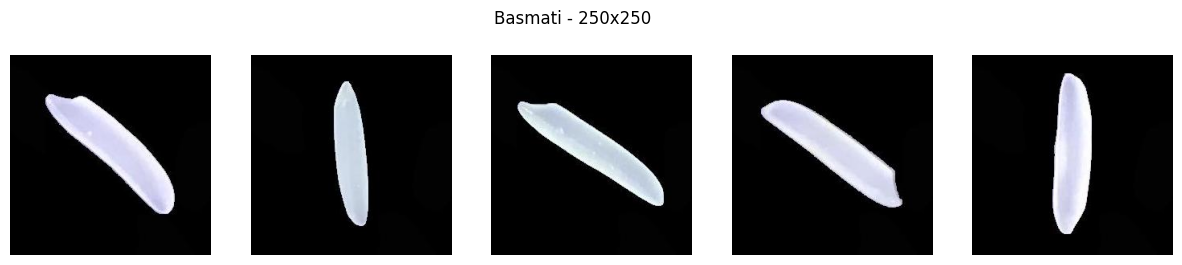

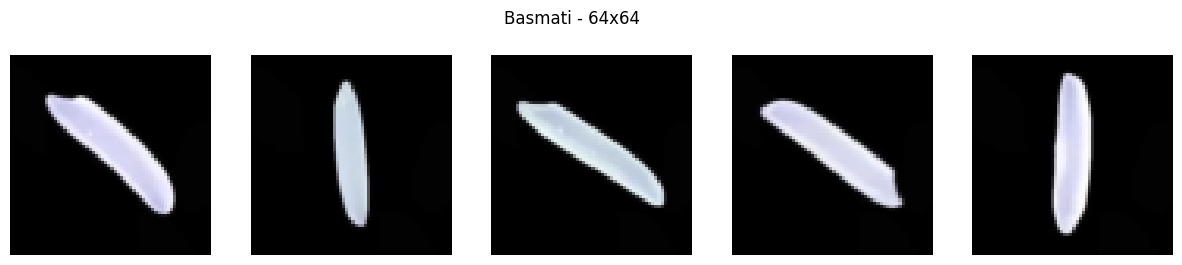

In [ ]:
selected_class = 'Basmati'
class_path = os.path.join(dataset_path, selected_class)

all_images = glob(os.path.join(class_path, '*'))

random_images = random.sample(all_images, 5)

def process_images(img_paths, size):
    transform = transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor()
    ])
    processed_imgs = []
    for path in img_paths:
        img = Image.open(path).convert('RGB')
        img_t = transform(img)
        processed_imgs.append(img_t)
    return processed_imgs

imgs_250 = process_images(random_images, 250)

imgs_128 = process_images(random_images, 64)

def show_images(imgs, title):
    plt.figure(figsize=(15,3))
    for i, img in enumerate(imgs):
        npimg = img.numpy().transpose(1,2,0)  # CxHxW -> HxWxC
        plt.subplot(1, len(imgs), i+1)
        plt.imshow(npimg)
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

show_images(imgs_250, f"{selected_class} - 250x250")
show_images(imgs_128, f"{selected_class} - 64x64")


In [ ]:
#train test
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

print("Train samples:", len(train_dataset))
print("Test samples :", len(test_dataset))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)


Train samples: 4000
Test samples : 1000


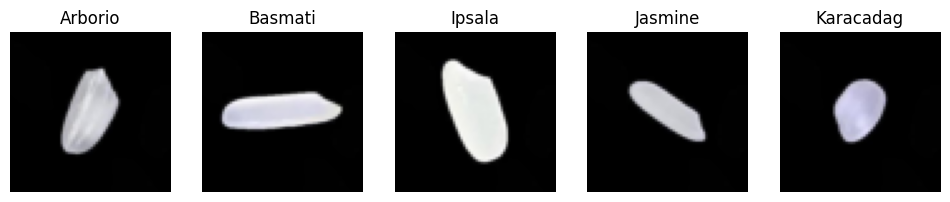

In [ ]:
class_to_indices = {cls: [] for cls in dataset.classes}

for i, (_, label) in enumerate(dataset.samples):
    class_to_indices[dataset.classes[label]].append(i)

sample_indices = [random.choice(class_to_indices[cls]) for cls in dataset.classes]

images = [dataset[i][0] for i in sample_indices]
labels = [dataset.classes[dataset[i][1]] for i in sample_indices]

images = [(img * 0.5 + 0.5) for img in images]

plt.figure(figsize=(12,5))
for i, img in enumerate(images):
    npimg = img.numpy().transpose(1,2,0)
    plt.subplot(1, len(images), i+1)
    plt.imshow(npimg)
    plt.title(labels[i])
    plt.axis("off")
plt.show()

In [ ]:
class CNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(64*8*8, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = correct / total
    train_loss = running_loss / total

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss /= val_total
    val_acc = val_correct / val_total

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

Epoch 1/10 | Train Loss: 0.4378 | Train Acc: 0.8335 | Val Loss: 0.0712 | Val Acc: 0.9830
Epoch 2/10 | Train Loss: 0.1281 | Train Acc: 0.9570 | Val Loss: 0.6105 | Val Acc: 0.7960
Epoch 3/10 | Train Loss: 0.1130 | Train Acc: 0.9670 | Val Loss: 0.2231 | Val Acc: 0.9200
Epoch 4/10 | Train Loss: 0.0900 | Train Acc: 0.9690 | Val Loss: 0.0335 | Val Acc: 0.9880
Epoch 5/10 | Train Loss: 0.0882 | Train Acc: 0.9715 | Val Loss: 0.1327 | Val Acc: 0.9510
Epoch 6/10 | Train Loss: 0.0697 | Train Acc: 0.9770 | Val Loss: 0.0418 | Val Acc: 0.9850
Epoch 7/10 | Train Loss: 0.0818 | Train Acc: 0.9700 | Val Loss: 0.4867 | Val Acc: 0.9170
Epoch 8/10 | Train Loss: 0.0606 | Train Acc: 0.9795 | Val Loss: 0.0930 | Val Acc: 0.9710
Epoch 9/10 | Train Loss: 0.0554 | Train Acc: 0.9798 | Val Loss: 0.0241 | Val Acc: 0.9930
Epoch 10/10 | Train Loss: 0.0528 | Train Acc: 0.9822 | Val Loss: 0.0317 | Val Acc: 0.9910


In [ ]:
#Here we could early stop on epoch 4->5, but in the end, the result are the best for epoch 9

#Which means the model is training good. I could achieve the lowest train loss
#by tuning layers and neurons, but now everything is good, and the runtime is pretty fast

b) import model pretrained

In [ ]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

transform = transforms.Compose([
    transforms.Resize((224, 224)), #all these params are must-have for pretrained models
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

dataset_path = '/kaggle/input/rice-image-dataset/Rice_Image_Dataset'
dataset = datasets.ImageFolder(root=dataset_path, transform=transform)

MAX_PER_CLASS = 1000
new_samples = []

targets = np.array([label for _, label in dataset.samples])

for class_id in range(len(dataset.classes)):
    class_idx = np.where(targets == class_id)[0]
    selected = np.random.choice(class_idx, MAX_PER_CLASS, replace=False)
    new_samples.extend([dataset.samples[i] for i in selected])

dataset.samples = new_samples
dataset.targets = [s[1] for s in new_samples]

dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

print("Classes:", dataset.classes)
print("Image amount:", len(dataset))

Classes: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']
Image amount: 5000


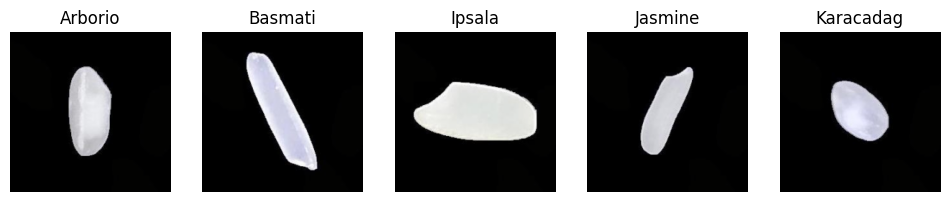

In [ ]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD  = np.array([0.229, 0.224, 0.225])

def denormalize(img):
    img = img.numpy().transpose(1, 2, 0)  # C,H,W -> H,W,C
    img = (img * IMAGENET_STD) + IMAGENET_MEAN
    img = np.clip(img, 0, 1)
    return img

class_to_indices = {cls: [] for cls in dataset.classes}
for i, (_, label) in enumerate(dataset.samples):
    class_to_indices[dataset.classes[label]].append(i)

sample_indices = [random.choice(class_to_indices[cls]) for cls in dataset.classes]

plt.figure(figsize=(12,5))
for i, idx in enumerate(sample_indices):
    img, label = dataset[idx]
    npimg = denormalize(img)
    plt.subplot(1, len(sample_indices), i+1)
    plt.imshow(npimg)
    plt.title(dataset.classes[label])
    plt.axis("off")

plt.show()


In [ ]:
#train test
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

print("Train samples:", len(train_dataset))
print("Test samples :", len(test_dataset))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

Train samples: 4000
Test samples : 1000


In [ ]:
#use model with weights param because pretrained is depricated
model = models.resnet18(pretrained=True)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning:

The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning:

Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 204MB/s]


In [ ]:
#use model with weights param because pretrained is depricated
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

In [ ]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
#Change out_features=1000 to match our classes=5
model.fc = nn.Linear(model.fc.in_features, 5)

In [ ]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_acc = correct / total

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss /= val_total
    val_acc = val_correct / val_total

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

Epoch 1/10 | Train Loss: 0.2044 | Train Acc: 0.9235 | Val Loss: 0.1892 | Val Acc: 0.9340
Epoch 2/10 | Train Loss: 0.0807 | Train Acc: 0.9715 | Val Loss: 0.0613 | Val Acc: 0.9800
Epoch 3/10 | Train Loss: 0.0592 | Train Acc: 0.9792 | Val Loss: 0.0973 | Val Acc: 0.9670
Epoch 4/10 | Train Loss: 0.0455 | Train Acc: 0.9840 | Val Loss: 0.9650 | Val Acc: 0.7320
Epoch 5/10 | Train Loss: 0.0369 | Train Acc: 0.9868 | Val Loss: 0.3571 | Val Acc: 0.8830
Epoch 6/10 | Train Loss: 0.0406 | Train Acc: 0.9885 | Val Loss: 0.0555 | Val Acc: 0.9820
Epoch 7/10 | Train Loss: 0.0342 | Train Acc: 0.9878 | Val Loss: 0.0264 | Val Acc: 0.9930
Epoch 8/10 | Train Loss: 0.0226 | Train Acc: 0.9922 | Val Loss: 0.9982 | Val Acc: 0.7380
Epoch 9/10 | Train Loss: 0.0705 | Train Acc: 0.9782 | Val Loss: 0.0784 | Val Acc: 0.9740
Epoch 10/10 | Train Loss: 0.0242 | Train Acc: 0.9905 | Val Loss: 0.0140 | Val Acc: 0.9960


In [ ]:
#Resnet runs better but longer, because its preconfigured model.
#It has far more complex structure and neurons\layers, and the speed to
#which it fits the best to my own is much faster

#Here after 2 epoch we can see a great decline, but then it picks up
#and begins to deliver good results. Regardless of some flactuations,
#epoch 10 delivers massive accuracy for test and train while also having
#the lowest losses possible, being the best model for these data.
#Might indicate overfitting, but for these data, i dont think it does

#Yet again, no early stopping because I wanted to show the model works and see what happens when it reaches the end.

# 3. Embedding (LSTM)


dataset from lab 2

#**About Dataset**

https://www.kaggle.com/code/i0nlyaziz/suicide-and-depression-text-classification


**Context**

When I thought of building a text classifier to detect Suicide Ideation I couldn't find any public dataset. Hope this can be useful to anyone looking for suicide detection datasets and can save their time 💜.

**Content**

The dataset is a collection of posts from the "SuicideWatch" and "depression" subreddits of the Reddit platform. The posts are collected using Pushshift API. All posts that were made to "SuicideWatch" from Dec 16, 2008(creation) till Jan 2, 2021, were collected while "depression" posts were collected from Jan 1, 2009, to Jan 2, 2021. All posts collected from SuicideWatch are labeled as suicide, While posts collected from the depression subreddit are labeled as depression. Non-suicide posts are collected from r/teenagers.

**Cite**

The dataset is originally published at Suicide Ideation Detection in Social Media Forums(https://ieeexplore.ieee.org/document/9591887)

**Version**

The current version has only suicide & non-suicide labels.
Version V13 has suicide, depression & teenagers(normal conversations) as labels.

**Collection**

A notebook is provided to show how posts from Reddit can be collected using PushShift API.

In [ ]:
''' Read in the whole dataset '''
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Suicide_Detection.csv");

In [ ]:
pd.set_option('display.max_colwidth', None)
df.head(10)

,Unnamed: 0,text,class
0,2,"Ex Wife Threatening SuicideRecently I left my wife for good because she has cheated on me twice and lied to me so much that I have decided to refuse to go back to her. As of a few days ago, she began threatening suicide. I have tirelessly spent these paat few days talking her out of it and she keeps hesitating because she wants to believe I'll come back. I know a lot of people will threaten this in order to get their way, but what happens if she really does? What do I do and how am I supposed to handle her death on my hands? I still love my wife but I cannot deal with getting cheated on again and constantly feeling insecure. I'm worried today may be the day she does it and I hope so much it doesn't happen.",suicide
1,3,Am I weird I don't get affected by compliments if it's coming from someone I know irl but I feel really good when internet strangers do it,non-suicide
2,4,"Finally 2020 is almost over... So I can never hear ""2020 has been a bad year"" ever again. I swear to fucking God it's so annoying",non-suicide
3,8,i need helpjust help me im crying so hard,suicide
4,9,"I’m so lostHello, my name is Adam (16) and I’ve been struggling for years and I’m afraid. Through these past years thoughts of suicide, fear, anxiety I’m so close to my limit . I’ve been quiet for so long and I’m too scared to come out to my family about these feelings. About 3 years ago losing my aunt triggered it all. Everyday feeling hopeless , lost, guilty, and remorseful over her and all the things I’ve done in my life,but thoughts like these with the little I’ve experienced in life? Only time I’ve revealed these feelings to my family is when I broke down where they saw my cuts. Watching them get so worried over something I portrayed as an average day made me feel absolutely dreadful. They later found out I was an attempt survivor from attempt OD(overdose from pills) and attempt hanging. All that happened was a blackout from the pills and I never went through with the noose because I’m still so afraid. During my first therapy I was diagnosed with severe depression, social anxiety, and a eating disorder.\nI was later transferred to a fucken group therapy for some reason which made me feel more anxious. Eventually before my last session with a 1 on 1 therapy she showed me my results from a daily check up on my feelings(which was a 2 - step survey for me and my mom/dad )\nCome to find out as I’ve been putting feeling horrible and afraid/anxious everyday , my mom has been doing I’ve been doing absolutely amazing with me described as “happiest she’s ever seen me, therapy has helped him” \nI eventually was put on Sertaline (anti anxiety or anti depression I’m sorry I forgot) but I never finished my first prescription nor ever found the right type of anti depressant because my mom thought I only wanted the drugs so she took me off my recommended pill schedule after ~3 week and stopped me from taking them. All this time I’ve been feeling worse afraid of the damage/ worry I’ve caused them even more. \nNow here with everything going on, I’m as afraid as I’ve ever been . I’ve relapsed on cutting and have developed severe insomnia . Day after day feeling more hopeless, worthless questioning why am I still here? What’s my motivation to move out of bed and keep going? I ask these to myself nearly every night almost having a break down everytime. \nPlease Please Please someone.. anyone help me.\nI’m so scared I might do something drastic, I’ve been shaped by fear and anxiety. Idk what to do anymore",suicide
5,11,"Honetly idkI dont know what im even doing here. I just feel like there is nothing and nowhere for me. All i can feel is either nothing or unbearably sad. Im ignoring friends every opitunity i can. I feel like im loosing my girlfriend. I only hurt everyone i talk too and i dont cause anything good. Im behind on my education, i feel alone but for the first time its not a feeling ive enjoyed. I have no hopes or dreams. I care about not

In [ ]:
df.drop(columns='Unnamed: 0',inplace=True)
df.head()

,text,class
0,Ex Wife Threatening SuicideRecently I left my ...,suicide
1,Am I weird I don't get affected by compliments...,non-suicide
2,Finally 2020 is almost over... So I can never ...,non-suicide
3,i need helpjust help me im crying so hard,suicide
4,"I’m so lostHello, my name is Adam (16) and I’v...",suicide


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232074 entries, 0 to 232073
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    232074 non-null  object
 1   class   232074 non-null  object
dtypes: object(2)
memory usage: 3.5+ MB


In [ ]:
df.dtypes.value_counts()

,count
object,2


In [ ]:
df.describe()

,text,class
count,232074,232074
unique,232074,2
top,I still haven't beaten the first boss in Hollow Knight. I've only fought it a few times and I always die really early in the fight. I'm terrible at this game y'all. :(,suicide
freq,1,116037


In [ ]:
df.shape

(232074, 2)

In [ ]:
df['class'].unique()

array(['suicide', 'non-suicide'], dtype=object)

In [ ]:
''' Get duplicates number '''
df.duplicated().sum()

np.int64(0)

# gjkhgjkdfjkggdf (if you dont know what this is, skip to the next section pls)


DISCLAIMER: Dear God, if you're unsure about what you're looking for here, please do yourself a favor and skip to the next section.

It might make more sense to you there. 🙏


In [2]:
''' Read in the whole dataset '''
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Suicide_Detection.csv");

# nltk.download('stopwords')
# stop_words = set(stopwords.words('english'))
nltk.download('punkt')
nltk.download('punkt_tab')

def clean_text(text):
    text = text.lower()
    text = re.sub(r"@\S+", " ", text)           # видаляє теги @username
    text = re.sub(r"https*\S+", " ", text)     # видаляє посилання
    text = re.sub(r"#\S+", " ", text)          # видаляє хештеги #tag
    text = re.sub(r"\d", " ", text)            # видаляє цифри
    text = re.sub(r'[%s]' % re.escape(string.punctuation), ' ', text)  # видаляє пунктуацію
    text = re.sub(r'\n', ' ', text)            # замінює перенос рядка на пробіл
    text = re.sub(r'\s{2,}',' ', text)         # замінює подвійні пробіли на один
    # text = ' '.join([word for word in text.split(' ') if word not in stop_words])
    return text

#after
df['clean_text'] = df['text'].apply(clean_text)

encoder = LabelEncoder()
df['class'] = encoder.fit_transform(df['class'])

X = df['clean_text']
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,random_state=42, stratify=y)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [3]:
print(df.text[0])

print()

df.clean_text[0]

Ex Wife Threatening SuicideRecently I left my wife for good because she has cheated on me twice and lied to me so much that I have decided to refuse to go back to her. As of a few days ago, she began threatening suicide. I have tirelessly spent these paat few days talking her out of it and she keeps hesitating because she wants to believe I'll come back. I know a lot of people will threaten this in order to get their way, but what happens if she really does? What do I do and how am I supposed to handle her death on my hands? I still love my wife but I cannot deal with getting cheated on again and constantly feeling insecure. I'm worried today may be the day she does it and I hope so much it doesn't happen.



'ex wife threatening suiciderecently i left my wife for good because she has cheated on me twice and lied to me so much that i have decided to refuse to go back to her as of a few days ago she began threatening suicide i have tirelessly spent these paat few days talking her out of it and she keeps hesitating because she wants to believe i ll come back i know a lot of people will threaten this in order to get their way but what happens if she really does what do i do and how am i supposed to handle her death on my hands i still love my wife but i cannot deal with getting cheated on again and constantly feeling insecure i m worried today may be the day she does it and i hope so much it doesn t happen '

In [4]:
cleaned_texts = df["clean_text"].tolist()
tokens = [word_tokenize(t) for t in cleaned_texts]
counter = Counter()
for tok_list in tokens:
    counter.update(tok_list)

vocab_size = len(counter)
print(f"Unique words amount: {vocab_size:,}")

Unique words amount: 157,414


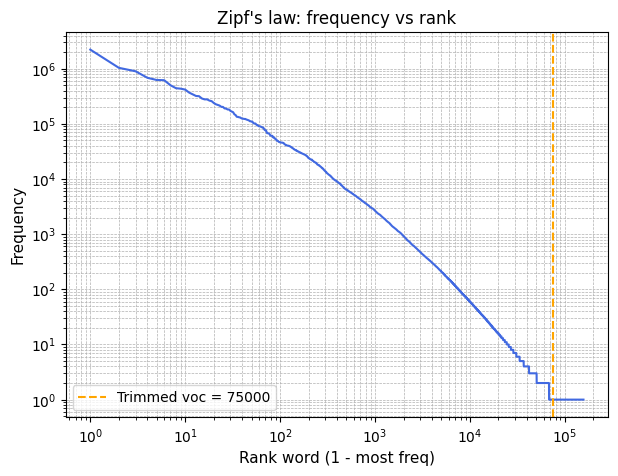

In [6]:
word_freqs = np.array(sorted(counter.values(), reverse=True))

ranks = np.arange(1, len(word_freqs) + 1)

plt.figure(figsize=(7, 5))
plt.loglog(ranks, word_freqs, color='royalblue')
plt.title("Zipf's law: frequency vs rank", fontsize=12)
plt.xlabel("Rank word (1 - most freq)", fontsize=11)
plt.ylabel("Frequency", fontsize=11)
plt.grid(True, which="both", ls="--", lw=0.5)

MAX_VOCAB = 75_000
plt.axvline(MAX_VOCAB, color='orange', linestyle='--',
            label=f'Trimmed voc = {MAX_VOCAB}')
plt.legend()

plt.show()

In [7]:
special_tokens = ["[PAD]", "[UNK]"]

most_common_words = counter.most_common(MAX_VOCAB - len(special_tokens))

itos = special_tokens + [word for word, _ in most_common_words]

stoi = {token: idx for idx, token in enumerate(itos)}

PAD_IDX = stoi["[PAD]"]
UNK_IDX = stoi["[UNK]"]

print("Voc size:", len(stoi))
print("Index of 'suicide':", stoi.get("suicide", UNK_IDX))


Voc size: 75000
Index of 'suicide': 136


In [8]:
def encode(token_list):
    return [stoi.get(token, UNK_IDX) for token in token_list]

encoded_texts = [encode(tok_list) for tok_list in tokens]

In [10]:
print("Tokens of first text:\n")
print(tokens[0][:20])
print("\n")

print("\nFirst 20 indexes:")
print(encoded_texts[0][:20])

print("Index of 'wife':", stoi.get("wife", UNK_IDX))


Tokens of first text:

['ex', 'wife', 'threatening', 'suiciderecently', 'i', 'left', 'my', 'wife', 'for', 'good', 'because', 'she', 'has', 'cheated', 'on', 'me', 'twice', 'and', 'lied', 'to']



First 20 indexes:
[502, 692, 2350, 68152, 2, 239, 7, 692, 18, 99, 52, 40, 87, 1322, 32, 11, 995, 4, 1363, 3]
Index of 'wife': 692


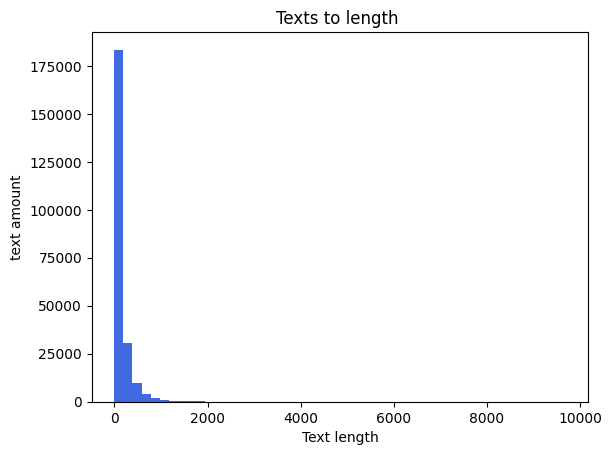

Max len: 9685
Mean len: 138.34227875591407
95th percentile: 493.0


In [11]:
lengths = [len(seq) for seq in encoded_texts]

plt.hist(lengths, bins=50, color='royalblue')
plt.xlabel("Text length")
plt.ylabel("text amount")
plt.title("Texts to length ")
plt.show()

print("Max len:", np.max(lengths))
print("Mean len:", np.mean(lengths))
print("95th percentile:", np.percentile(lengths, 95))

In [12]:
MAX_LEN = 350

def pad_sequence(seq):
    seq = seq[:MAX_LEN]

    seq = seq + [PAD_IDX] * (MAX_LEN - len(seq))
    return torch.tensor(seq, dtype=torch.long)

X = torch.stack([pad_sequence(seq) for seq in encoded_texts])

print("Shape X:", X.shape)


Shape X: torch.Size([232074, 350])


In [13]:
torch.set_printoptions(threshold=400)

first_tokens = tokens[0]
print("Original tokens (first text):")
print(first_tokens[:351], "...")

first_encoded_padded = X[0]
print("\nEncoded + padded (first text):")
print(first_encoded_padded[:351], "...")


Original tokens (first text):
['ex', 'wife', 'threatening', 'suiciderecently', 'i', 'left', 'my', 'wife', 'for', 'good', 'because', 'she', 'has', 'cheated', 'on', 'me', 'twice', 'and', 'lied', 'to', 'me', 'so', 'much', 'that', 'i', 'have', 'decided', 'to', 'refuse', 'to', 'go', 'back', 'to', 'her', 'as', 'of', 'a', 'few', 'days', 'ago', 'she', 'began', 'threatening', 'suicide', 'i', 'have', 'tirelessly', 'spent', 'these', 'paat', 'few', 'days', 'talking', 'her', 'out', 'of', 'it', 'and', 'she', 'keeps', 'hesitating', 'because', 'she', 'wants', 'to', 'believe', 'i', 'll', 'come', 'back', 'i', 'know', 'a', 'lot', 'of', 'people', 'will', 'threaten', 'this', 'in', 'order', 'to', 'get', 'their', 'way', 'but', 'what', 'happens', 'if', 'she', 'really', 'does', 'what', 'do', 'i', 'do', 'and', 'how', 'am', 'i', 'supposed', 'to', 'handle', 'her', 'death', 'on', 'my', 'hands', 'i', 'still', 'love', 'my', 'wife', 'but', 'i', 'can', 'not', 'deal', 'with', 'getting', 'cheated', 'on', 'again', 'and',

In [14]:
# how PAD works (is 0)
long_text_idx = None
short_text_idx = None

for i, seq in enumerate(encoded_texts):
    if len(seq) > MAX_LEN and long_text_idx is None:
        long_text_idx = i
    if len(seq) < MAX_LEN and short_text_idx is None:
        short_text_idx = i
    if long_text_idx is not None and short_text_idx is not None:
        break

print("Long text (> MAX_LEN):", long_text_idx, "len =", len(encoded_texts[long_text_idx]))
print("Short text (< MAX_LEN):", short_text_idx, "len =", len(encoded_texts[short_text_idx]))

print("\nEncoded (original) long text, first 120 tokens:")
print(encoded_texts[long_text_idx][:120])

print("\nEncoded (original) short text:")
print(encoded_texts[short_text_idx])

long_padded = pad_sequence(encoded_texts[long_text_idx])
short_padded = pad_sequence(encoded_texts[short_text_idx])

print("\nPadded long text (length = MAX_LEN):")
print(long_padded)

print("\nPadded short text (length = MAX_LEN):")
print(short_padded)


Long text (> MAX_LEN): 4 len = 476
Short text (< MAX_LEN): 0 len = 147

Encoded (original) long text, first 120 tokens:
[2, 13, 15, 22, 30807, 7, 534, 17, 5267, 4, 2, 13, 45, 57, 690, 18, 92, 4, 2, 13, 15, 418, 164, 231, 264, 92, 222, 10, 136, 519, 301, 2, 13, 15, 22, 317, 3, 7, 2521, 2, 13, 45, 57, 1341, 18, 22, 183, 4, 2, 13, 15, 100, 283, 3, 250, 47, 3, 7, 119, 37, 231, 415, 37, 92, 220, 637, 7, 1865, 2430, 8, 35, 421, 191, 914, 261, 967, 4, 14279, 120, 54, 4, 35, 5, 95, 2, 13, 45, 210, 14, 7, 44, 16, 222, 29, 231, 26, 5, 248, 2, 13, 45, 1390, 14, 44, 78, 65, 2, 13, 45, 5178, 231, 415, 3, 7, 119, 17, 62, 2, 451, 185]

Encoded (original) short text:
[502, 692, 2350, 68152, 2, 239, 7, 692, 18, 99, 52, 40, 87, 1322, 32, 11, 995, 4, 1363, 3, 11, 22, 83, 12, 2, 19, 409, 3, 1734, 3, 74, 111, 3, 54, 55, 10, 6, 189, 224, 220, 40, 1104, 2350, 136, 2, 19, 15027, 547, 231, 68153, 189, 224, 288, 54, 47, 10, 8, 4, 40, 714, 10629, 52, 40, 363, 3, 351, 2, 107, 250, 111, 2, 38, 6, 199, 10, 59, 69, 

In [15]:
#how UNK works (is 1)
new_text = "hello razik in this example"
tokens = word_tokenize(new_text)

encoded = encode(tokens)

print("Tokens:", tokens)
print("Encoded indices:", encoded)
print("UNK_IDX:", UNK_IDX)

for t, idx in zip(tokens, encoded):
    if idx == UNK_IDX:
        print(f"'{t}' → UNK_IDX")

Tokens: ['hello', 'razik', 'in', 'this', 'example']
Encoded indices: [1063, 1, 14, 21, 1354]
UNK_IDX: 1
'razik' → UNK_IDX


In [16]:
MAX_LEN = 350
BATCH_SIZE = 128

def pad_sequence(seq):
    seq = seq[:MAX_LEN] + [PAD_IDX] * max(0, MAX_LEN - len(seq))
    return torch.tensor(seq, dtype=torch.long)

tokens = [word_tokenize(text) for text in df['clean_text']]
encoded_texts = [[stoi.get(tok, UNK_IDX) for tok in tok_list] for tok_list in tokens]

X = torch.stack([pad_sequence(seq) for seq in encoded_texts])
y = torch.tensor(df['class'].values, dtype=torch.long)

dataset = TensorDataset(X, y)

N = len(dataset)
train_size = int(0.7 * N)
val_size   = int(0.15 * N)
test_size  = N - train_size - val_size

train_ds, val_ds, test_ds = random_split(dataset, [train_size, val_size, test_size],
                                         generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")


Train batches: 1270, Val batches: 272, Test batches: 272


In [17]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
VOCAB_SIZE = len(stoi)
EMBEDDING_DIM = 100
HIDDEN_DIM = 128
OUTPUT_DIM = len(df['class'].unique())
NUM_LAYERS = 1
DROPOUT = 0.3
EPOCHS = 10

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim,
                 num_layers=1, dropout=0.3, pad_idx=PAD_IDX):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)                 # [batch, seq_len, emb_dim]
        _, (hidden, _) = self.lstm(embedded)        # hidden: [num_layers, batch, hidden_dim]
        out = self.fc(hidden[-1])                   # беремо останній шар
        return out

model = LSTMClassifier(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM,
                       NUM_LAYERS, DROPOUT, PAD_IDX).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0
    correct = 0
    total = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total
    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning:

dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1



Epoch 1/10 | Train Loss: 0.3908 | Train Acc: 0.8040 | Val Loss: 0.2027 | Val Acc: 0.9274
Epoch 2/10 | Train Loss: 0.1720 | Train Acc: 0.9371 | Val Loss: 0.1637 | Val Acc: 0.9390
Epoch 3/10 | Train Loss: 0.1336 | Train Acc: 0.9523 | Val Loss: 0.1552 | Val Acc: 0.9428
Epoch 4/10 | Train Loss: 0.1068 | Train Acc: 0.9628 | Val Loss: 0.1481 | Val Acc: 0.9454
Epoch 5/10 | Train Loss: 0.0847 | Train Acc: 0.9716 | Val Loss: 0.1527 | Val Acc: 0.9445
Epoch 6/10 | Train Loss: 0.0653 | Train Acc: 0.9789 | Val Loss: 0.1770 | Val Acc: 0.9444
Epoch 7/10 | Train Loss: 0.0495 | Train Acc: 0.9846 | Val Loss: 0.1997 | Val Acc: 0.9424
Epoch 8/10 | Train Loss: 0.0382 | Train Acc: 0.9885 | Val Loss: 0.2024 | Val Acc: 0.9429
Epoch 9/10 | Train Loss: 0.0304 | Train Acc: 0.9910 | Val Loss: 0.2281 | Val Acc: 0.9394
Epoch 10/10 | Train Loss: 0.0249 | Train Acc: 0.9929 | Val Loss: 0.2517 | Val Acc: 0.9411


In [ ]:
#my model runs for 5mins (10 epochs)

#it can be seen that it does learn and train,
#losses are gradually going down and accuracy is increasing,
#there are some flactuations though

#

In [18]:
model.eval()
test_loss = 0
test_correct = 0
test_total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)

test_loss /= test_total
test_acc = test_correct / test_total
print(f"\nTest Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")



Test Loss: 0.2578 | Test Acc: 0.9417


In [19]:
#loss and accuracy are much lower, which may indicate overfitting
#but in real world, thats totally fine, and also its the dataset and splitting
#moreover, the loss is identical to val loss for 10 epochs with accuracy being the same

#this all means model works good and pretty fast for text data

In [23]:
!wget -q http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

In [40]:
def load_glove_txt(path):
    vectors = {}
    with open(path, "r", encoding="utf8") as f:
        for line in f:
            parts = line.rstrip().split(" ")
            word = parts[0]
            vec = np.asarray(parts[1:], dtype=np.float32)
            vectors[word] = vec
    dim = len(next(iter(vectors.values())))
    return vectors, dim

glove_path = "glove.6B.50d.txt"
glove, emb_dim = load_glove_txt(glove_path)

print("GloVe dim:", emb_dim)
print("Entries in GloVe:", len(glove))

GloVe dim: 50
Entries in GloVe: 400000


In [41]:
#приклад embeddings
for w in ["die", "suicide", "love", "goodbye"]:
    print(w, glove[w][:10])

die [ 0.70671  -0.21417   0.75421  -1.8482    0.015824  0.19635   0.61256
  0.89881   0.32359  -0.11349 ]
suicide [ 1.1757e+00 -3.2014e-01  6.0612e-01 -7.8672e-01  6.3431e-01  1.1939e+00
  7.6198e-03  8.9170e-04  3.4835e-01  1.3682e-01]
love [-0.13886    1.1401    -0.85212   -0.29212    0.75534    0.82762
 -0.3181     0.0072204 -0.34762    1.0731   ]
goodbye [-0.1252   0.91598 -0.15958 -0.459    0.34854 -0.26754 -0.48121  0.98226
 -0.77214  0.34111]


In [42]:
vocab_size = len(stoi)
PAD_IDX = stoi["[PAD]"]
UNK_IDX = stoi["[UNK]"]

emb_matrix = np.random.normal(scale=0.1, size=(vocab_size, emb_dim)).astype(np.float32)
emb_matrix[PAD_IDX] = 0.0

hit = 0
for w, idx in stoi.items():
    v = glove.get(w)
    if v is not None:
        emb_matrix[idx] = v
        hit += 1

print(f"Coverage: {hit}/{vocab_size} = {hit/vocab_size:.1%}")

Coverage: 46561/75000 = 62.1%


In [34]:
pretrained_emb = torch.nn.Embedding.from_pretrained(
    torch.tensor(emb_matrix),
    freeze=True,
    padding_idx=PAD_IDX
)

In [43]:
!wget http://nlp.stanford.edu/data/glove.42B.300d.zip
!unzip glove.42B.300d.zip

--2025-11-30 18:13:39--  http://nlp.stanford.edu/data/glove.42B.300d.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.42B.300d.zip [following]
--2025-11-30 18:13:39--  https://nlp.stanford.edu/data/glove.42B.300d.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.42B.300d.zip [following]
--2025-11-30 18:13:39--  https://downloads.cs.stanford.edu/nlp/data/glove.42B.300d.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1877800501 (1.7G) [application/zip]


In [50]:
def load_glove_txt(path):
    vectors = {}
    with open(path, "r", encoding="utf8") as f:
        for line in f:
            parts = line.rstrip().split(" ")
            word = parts[0]
            vec = np.asarray(parts[1:], dtype=np.float32)
            vectors[word] = vec
    dim = len(next(iter(vectors.values())))
    return vectors, dim

glove_path = "glove.42B.300d.txt"
glove, emb_dim = load_glove_txt(glove_path)

print("GloVe dim:", emb_dim)
print("Entries in GloVe:", len(glove))

GloVe dim: 300
Entries in GloVe: 1917494


In [51]:
vocab_size = len(stoi)
PAD_IDX = stoi["[PAD]"]
UNK_IDX = stoi["[UNK]"]

emb_matrix = np.random.normal(scale=0.1, size=(vocab_size, emb_dim)).astype(np.float32)
emb_matrix[PAD_IDX] = 0.0

hit = 0
for w, idx in stoi.items():
    v = glove.get(w)
    if v is not None:
        emb_matrix[idx] = v
        hit += 1

print(f"Coverage: {hit}/{vocab_size} = {hit/vocab_size:.1%}")

Coverage: 58365/75000 = 77.8%


In [54]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
VOCAB_SIZE = len(stoi)
EMBEDDING_DIM = 300   # для GloVe 42B 300d
HIDDEN_DIM = 128
OUTPUT_DIM = len(df['class'].unique())
NUM_LAYERS = 1
DROPOUT = 0.3

# Створюємо модель
model_glove = LSTMClassifier(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM,
                             NUM_LAYERS, DROPOUT, PAD_IDX).to(DEVICE)


# Підставляємо у модель
pretrained_emb = nn.Embedding.from_pretrained(
    torch.tensor(emb_matrix, dtype=torch.float32),
    freeze=True,           # заморозити під час тренування
    padding_idx=PAD_IDX
).to(DEVICE)

model_glove.embedding = pretrained_emb

In [55]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_glove.parameters(), lr=0.001)

for epoch in range(EPOCHS):
    model_glove.train()
    running_loss = 0
    correct = 0
    total = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model_glove(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    model_glove.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model_glove(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total
    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")


Epoch 1/10 | Train Loss: 0.3816 | Train Acc: 0.8252 | Val Loss: 0.2078 | Val Acc: 0.9159
Epoch 2/10 | Train Loss: 0.1719 | Train Acc: 0.9369 | Val Loss: 0.1549 | Val Acc: 0.9416
Epoch 3/10 | Train Loss: 0.1399 | Train Acc: 0.9486 | Val Loss: 0.1416 | Val Acc: 0.9470
Epoch 4/10 | Train Loss: 0.1210 | Train Acc: 0.9554 | Val Loss: 0.1269 | Val Acc: 0.9517
Epoch 5/10 | Train Loss: 0.1071 | Train Acc: 0.9609 | Val Loss: 0.1274 | Val Acc: 0.9521
Epoch 6/10 | Train Loss: 0.0931 | Train Acc: 0.9659 | Val Loss: 0.1249 | Val Acc: 0.9548
Epoch 7/10 | Train Loss: 0.0808 | Train Acc: 0.9708 | Val Loss: 0.1300 | Val Acc: 0.9552
Epoch 8/10 | Train Loss: 0.0686 | Train Acc: 0.9755 | Val Loss: 0.1386 | Val Acc: 0.9522
Epoch 9/10 | Train Loss: 0.0583 | Train Acc: 0.9795 | Val Loss: 0.1466 | Val Acc: 0.9531
Epoch 10/10 | Train Loss: 0.0489 | Train Acc: 0.9830 | Val Loss: 0.1605 | Val Acc: 0.9500


In [ ]:
#this runs a little better but longer (by the time my code finished - it was only
#epoch 7 for GloVe)
#better - because its generally accepted embedding

#results and losses are also fantastic


In [56]:
model_glove.eval()
test_loss = 0
test_correct = 0
test_total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        outputs = model_glove(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)

test_loss /= test_total
test_acc = test_correct / test_total
print(f"\nTest Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")



Test Loss: 0.1683 | Test Acc: 0.9489


In [ ]:
#test loss is lower, but acc is a little higher


#With nearly identical params (300d)

In [ ]:
''' Read in the whole dataset '''
df = pd.read_csv("/kaggle/input/suicide-watch/Suicide_Detection.csv");

# nltk.download('stopwords')
# stop_words = set(stopwords.words('english'))
nltk.download('punkt')
nltk.download('punkt_tab')

def clean_text(text):
    text = text.lower()
    text = re.sub(r"@\S+", " ", text)           # видаляє теги @username
    text = re.sub(r"https*\S+", " ", text)     # видаляє посилання
    text = re.sub(r"#\S+", " ", text)          # видаляє хештеги #tag
    text = re.sub(r"\d", " ", text)            # видаляє цифри
    text = re.sub(r'[%s]' % re.escape(string.punctuation), ' ', text)  # видаляє пунктуацію
    text = re.sub(r'\n', ' ', text)            # замінює перенос рядка на пробіл
    text = re.sub(r'\s{2,}',' ', text)         # замінює подвійні пробіли на один
    # text = ' '.join([word for word in text.split(' ') if word not in stop_words])
    return text

#after
df['clean_text'] = df['text'].apply(clean_text)

encoder = LabelEncoder()
df['class'] = encoder.fit_transform(df['class'])

X = df['clean_text']
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,random_state=42, stratify=y)

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
print(df.text[0])

print()

df.clean_text[0]

Ex Wife Threatening SuicideRecently I left my wife for good because she has cheated on me twice and lied to me so much that I have decided to refuse to go back to her. As of a few days ago, she began threatening suicide. I have tirelessly spent these paat few days talking her out of it and she keeps hesitating because she wants to believe I'll come back. I know a lot of people will threaten this in order to get their way, but what happens if she really does? What do I do and how am I supposed to handle her death on my hands? I still love my wife but I cannot deal with getting cheated on again and constantly feeling insecure. I'm worried today may be the day she does it and I hope so much it doesn't happen.



'ex wife threatening suiciderecently i left my wife for good because she has cheated on me twice and lied to me so much that i have decided to refuse to go back to her as of a few days ago she began threatening suicide i have tirelessly spent these paat few days talking her out of it and she keeps hesitating because she wants to believe i ll come back i know a lot of people will threaten this in order to get their way but what happens if she really does what do i do and how am i supposed to handle her death on my hands i still love my wife but i cannot deal with getting cheated on again and constantly feeling insecure i m worried today may be the day she does it and i hope so much it doesn t happen '

In [ ]:
cleaned_texts = df["clean_text"].tolist()
tokens = [word_tokenize(t) for t in cleaned_texts]
counter = Counter()
for tok_list in tokens:
    counter.update(tok_list)

vocab_size = len(counter)
print(f"Unique words amount: {vocab_size:,}")

Unique words amount: 157,414


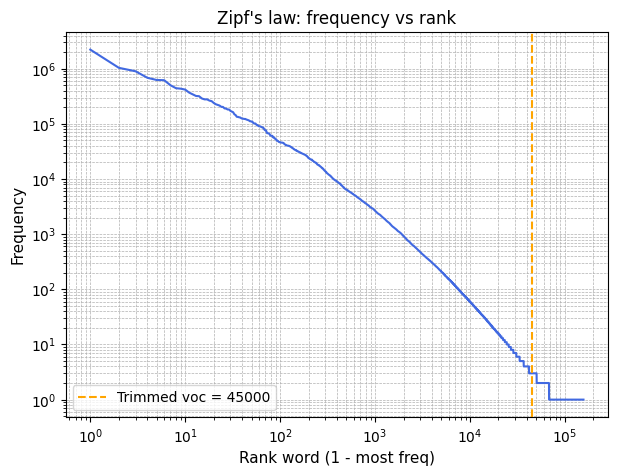

In [ ]:
word_freqs = np.array(sorted(counter.values(), reverse=True))

ranks = np.arange(1, len(word_freqs) + 1)

plt.figure(figsize=(7, 5))
plt.loglog(ranks, word_freqs, color='royalblue')
plt.title("Zipf's law: frequency vs rank", fontsize=12)
plt.xlabel("Rank word (1 - most freq)", fontsize=11)
plt.ylabel("Frequency", fontsize=11)
plt.grid(True, which="both", ls="--", lw=0.5)

MAX_VOCAB = 45_000
plt.axvline(MAX_VOCAB, color='orange', linestyle='--',
            label=f'Trimmed voc = {MAX_VOCAB}')
plt.legend()

plt.show()

In [ ]:
special_tokens = ["[PAD]", "[UNK]"]

most_common_words = counter.most_common(MAX_VOCAB - len(special_tokens))

itos = special_tokens + [word for word, _ in most_common_words]

stoi = {token: idx for idx, token in enumerate(itos)}

PAD_IDX = stoi["[PAD]"]
UNK_IDX = stoi["[UNK]"]

print("Voc size:", len(stoi))
print("Index of 'suicide':", stoi.get("suicide", UNK_IDX))


Voc size: 45000
Index of 'suicide': 136


In [ ]:
def encode(token_list):
    return [stoi.get(token, UNK_IDX) for token in token_list]

encoded_texts = [encode(tok_list) for tok_list in tokens]

In [ ]:
print("Tokens of first text:\n")
print(tokens[0][:20])
print("\n")

print("\nFirst 20 indexes:")
print(encoded_texts[0][:20])

print("Index of 'wife':", stoi.get("wife", UNK_IDX))


Tokens of first text:

['ex', 'wife', 'threatening', 'suiciderecently', 'i', 'left', 'my', 'wife', 'for', 'good', 'because', 'she', 'has', 'cheated', 'on', 'me', 'twice', 'and', 'lied', 'to']



First 20 indexes:
[502, 692, 2350, 1, 2, 239, 7, 692, 18, 99, 52, 40, 87, 1322, 32, 11, 995, 4, 1363, 3]
Index of 'wife': 692


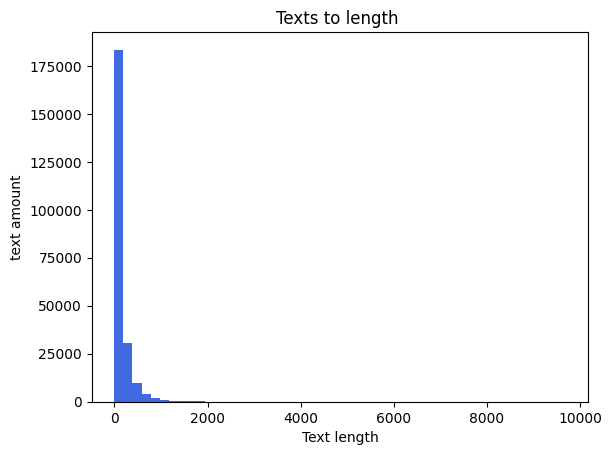

Max len: 9685
Mean len: 138.34227875591407
95th percentile: 493.0


In [ ]:
lengths = [len(seq) for seq in encoded_texts]

plt.hist(lengths, bins=50, color='royalblue')
plt.xlabel("Text length")
plt.ylabel("text amount")
plt.title("Texts to length ")
plt.show()

print("Max len:", np.max(lengths))
print("Mean len:", np.mean(lengths))
print("95th percentile:", np.percentile(lengths, 95))

In [ ]:
MAX_LEN = 350

def pad_sequence(seq):
    seq = seq[:MAX_LEN]

    seq = seq + [PAD_IDX] * (MAX_LEN - len(seq))
    return torch.tensor(seq, dtype=torch.long)

X = torch.stack([pad_sequence(seq) for seq in encoded_texts])

print("Shape X:", X.shape)

Shape X: torch.Size([232074, 350])


In [ ]:
torch.set_printoptions(threshold=400)

first_tokens = tokens[0]
print("Original tokens (first text):")
print(first_tokens[:351], "...")

first_encoded_padded = X[0]
print("\nEncoded + padded (first text):")
print(first_encoded_padded[:351], "...")


Original tokens (first text):
['ex', 'wife', 'threatening', 'suiciderecently', 'i', 'left', 'my', 'wife', 'for', 'good', 'because', 'she', 'has', 'cheated', 'on', 'me', 'twice', 'and', 'lied', 'to', 'me', 'so', 'much', 'that', 'i', 'have', 'decided', 'to', 'refuse', 'to', 'go', 'back', 'to', 'her', 'as', 'of', 'a', 'few', 'days', 'ago', 'she', 'began', 'threatening', 'suicide', 'i', 'have', 'tirelessly', 'spent', 'these', 'paat', 'few', 'days', 'talking', 'her', 'out', 'of', 'it', 'and', 'she', 'keeps', 'hesitating', 'because', 'she', 'wants', 'to', 'believe', 'i', 'll', 'come', 'back', 'i', 'know', 'a', 'lot', 'of', 'people', 'will', 'threaten', 'this', 'in', 'order', 'to', 'get', 'their', 'way', 'but', 'what', 'happens', 'if', 'she', 'really', 'does', 'what', 'do', 'i', 'do', 'and', 'how', 'am', 'i', 'supposed', 'to', 'handle', 'her', 'death', 'on', 'my', 'hands', 'i', 'still', 'love', 'my', 'wife', 'but', 'i', 'can', 'not', 'deal', 'with', 'getting', 'cheated', 'on', 'again', 'and',

In [ ]:
# how PAD works (is 0)
long_text_idx = None
short_text_idx = None

for i, seq in enumerate(encoded_texts):
    if len(seq) > MAX_LEN and long_text_idx is None:
        long_text_idx = i
    if len(seq) < MAX_LEN and short_text_idx is None:
        short_text_idx = i
    if long_text_idx is not None and short_text_idx is not None:
        break

print("Long text (> MAX_LEN):", long_text_idx, "len =", len(encoded_texts[long_text_idx]))
print("Short text (< MAX_LEN):", short_text_idx, "len =", len(encoded_texts[short_text_idx]))

print("\nEncoded (original) long text, first 120 tokens:")
print(encoded_texts[long_text_idx][:120])

print("\nEncoded (original) short text:")
print(encoded_texts[short_text_idx])

long_padded = pad_sequence(encoded_texts[long_text_idx])
short_padded = pad_sequence(encoded_texts[short_text_idx])

print("\nPadded long text (length = MAX_LEN):")
print(long_padded)

print("\nPadded short text (length = MAX_LEN):")
print(short_padded)


Long text (> MAX_LEN): 4 len = 476
Short text (< MAX_LEN): 0 len = 147

Encoded (original) long text, first 120 tokens:
[2, 13, 15, 22, 30807, 7, 534, 17, 5267, 4, 2, 13, 45, 57, 690, 18, 92, 4, 2, 13, 15, 418, 164, 231, 264, 92, 222, 10, 136, 519, 301, 2, 13, 15, 22, 317, 3, 7, 2521, 2, 13, 45, 57, 1341, 18, 22, 183, 4, 2, 13, 15, 100, 283, 3, 250, 47, 3, 7, 119, 37, 231, 415, 37, 92, 220, 637, 7, 1865, 2430, 8, 35, 421, 191, 914, 261, 967, 4, 14279, 120, 54, 4, 35, 5, 95, 2, 13, 45, 210, 14, 7, 44, 16, 222, 29, 231, 26, 5, 248, 2, 13, 45, 1390, 14, 44, 78, 65, 2, 13, 45, 5178, 231, 415, 3, 7, 119, 17, 62, 2, 451, 185]

Encoded (original) short text:
[502, 692, 2350, 1, 2, 239, 7, 692, 18, 99, 52, 40, 87, 1322, 32, 11, 995, 4, 1363, 3, 11, 22, 83, 12, 2, 19, 409, 3, 1734, 3, 74, 111, 3, 54, 55, 10, 6, 189, 224, 220, 40, 1104, 2350, 136, 2, 19, 15027, 547, 231, 1, 189, 224, 288, 54, 47, 10, 8, 4, 40, 714, 10629, 52, 40, 363, 3, 351, 2, 107, 250, 111, 2, 38, 6, 199, 10, 59, 69, 3538, 21

In [ ]:
#how UNK works (is 1)
new_text = "hello razik in this example"
tokens = word_tokenize(new_text)

encoded = encode(tokens)

print("Tokens:", tokens)
print("Encoded indices:", encoded)
print("UNK_IDX:", UNK_IDX)

for t, idx in zip(tokens, encoded):
    if idx == UNK_IDX:
        print(f"'{t}' → UNK_IDX")

Tokens: ['hello', 'razik', 'in', 'this', 'example']
Encoded indices: [1063, 1, 14, 21, 1354]
UNK_IDX: 1
'razik' → UNK_IDX


In [ ]:
MAX_LEN = 350
BATCH_SIZE = 128

def pad_sequence(seq):
    seq = seq[:MAX_LEN] + [PAD_IDX] * max(0, MAX_LEN - len(seq))
    return torch.tensor(seq, dtype=torch.long)

tokens = [word_tokenize(text) for text in df['clean_text']]
encoded_texts = [[stoi.get(tok, UNK_IDX) for tok in tok_list] for tok_list in tokens]

X = torch.stack([pad_sequence(seq) for seq in encoded_texts])
y = torch.tensor(df['class'].values, dtype=torch.long)

dataset = TensorDataset(X, y)

N = len(dataset)
train_size = int(0.7 * N)
val_size   = int(0.15 * N)
test_size  = N - train_size - val_size

train_ds, val_ds, test_ds = random_split(dataset, [train_size, val_size, test_size],
                                         generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")


Train batches: 1270, Val batches: 272, Test batches: 272


In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
VOCAB_SIZE = len(stoi)
EMBEDDING_DIM = 300
HIDDEN_DIM = 128
OUTPUT_DIM = len(df['class'].unique())
NUM_LAYERS = 1
DROPOUT = 0.3
EPOCHS = 10

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim,
                 num_layers=1, dropout=0.3, pad_idx=PAD_IDX):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)                 # [batch, seq_len, emb_dim]
        _, (hidden, _) = self.lstm(embedded)        # hidden: [num_layers, batch, hidden_dim]
        out = self.fc(hidden[-1])
        return out

model = LSTMClassifier(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM,
                       NUM_LAYERS, DROPOUT, PAD_IDX).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0
    correct = 0
    total = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total
    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

cuda
Epoch 1/10 | Train Loss: 0.5744 | Train Acc: 0.6662 | Val Loss: 0.3236 | Val Acc: 0.8812
Epoch 2/10 | Train Loss: 0.2333 | Train Acc: 0.9117 | Val Loss: 0.1878 | Val Acc: 0.9327
Epoch 3/10 | Train Loss: 0.1569 | Train Acc: 0.9435 | Val Loss: 0.1619 | Val Acc: 0.9424
Epoch 4/10 | Train Loss: 0.1198 | Train Acc: 0.9579 | Val Loss: 0.1582 | Val Acc: 0.9450
Epoch 5/10 | Train Loss: 0.0930 | Train Acc: 0.9690 | Val Loss: 0.1631 | Val Acc: 0.9453
Epoch 6/10 | Train Loss: 0.0734 | Train Acc: 0.9764 | Val Loss: 0.1775 | Val Acc: 0.9459
Epoch 7/10 | Train Loss: 0.0581 | Train Acc: 0.9818 | Val Loss: 0.1953 | Val Acc: 0.9393
Epoch 8/10 | Train Loss: 0.0459 | Train Acc: 0.9864 | Val Loss: 0.2001 | Val Acc: 0.9436
Epoch 9/10 | Train Loss: 0.0383 | Train Acc: 0.9889 | Val Loss: 0.2070 | Val Acc: 0.9435
Epoch 10/10 | Train Loss: 0.0317 | Train Acc: 0.9911 | Val Loss: 0.2135 | Val Acc: 0.9418


In [ ]:
model.eval()
test_loss = 0
test_correct = 0
test_total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)

test_loss /= test_total
test_acc = test_correct / test_total
print(f"\nTest Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")


Test Loss: 0.2160 | Test Acc: 0.9427


In [ ]:
#i chose 300d because for other gloves (50d, 100d), the coverage was very low (60-70%)

#it can be seen that the model does learn and train,
#losses are gradually going down and accuracy is increasing,
#there are some flactuations though, especially for val loss
#i didnt do early stopping here, because i wanted to see how the model will change itself further

In [ ]:
#choose this glove because others dont have enough words for my dataset
!wget http://nlp.stanford.edu/data/glove.42B.300d.zip
!unzip glove.42B.300d.zip

--2025-11-30 19:12:48--  http://nlp.stanford.edu/data/glove.42B.300d.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.42B.300d.zip [following]
--2025-11-30 19:12:48--  https://nlp.stanford.edu/data/glove.42B.300d.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.42B.300d.zip [following]
--2025-11-30 19:12:48--  https://downloads.cs.stanford.edu/nlp/data/glove.42B.300d.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1877800501 (1.7G) [application/zip]


In [ ]:
def load_glove_txt(path):
    vectors = {}
    with open(path, "r", encoding="utf8") as f:
        for line in f:
            parts = line.rstrip().split(" ")
            word = parts[0]
            vec = np.asarray(parts[1:], dtype=np.float32)
            vectors[word] = vec
    dim = len(next(iter(vectors.values())))
    return vectors, dim

glove_path = "glove.42B.300d.txt"
glove, emb_dim = load_glove_txt(glove_path)

print("GloVe dim:", emb_dim)
print("Entries in GloVe:", len(glove))

GloVe dim: 300
Entries in GloVe: 1917494


In [ ]:
#embeddings
for w in ["die", "suicide", "love", "goodbye"]:
    print(w, glove[w][:10])

die [-0.62889    0.13025    0.0060798  0.82514   -0.016548   0.41543
 -2.7475     0.42997    0.13254   -0.6544   ]
suicide [ 0.16763   0.10143  -0.3368    0.4579   -0.51734   0.26675  -2.3898
  0.53078  -0.55851  -0.043048]
love [-0.14928   -0.0068072 -0.24947    0.094759   0.077483   0.15703
 -3.4127    -0.71732   -0.4116    -0.96051  ]
goodbye [ 0.36122  -0.32684  -0.0803    0.39861  -0.20158   0.070627 -1.574
 -0.20544  -0.31473  -0.89059 ]


In [ ]:
vocab_size = len(stoi)
PAD_IDX = stoi["[PAD]"]
UNK_IDX = stoi["[UNK]"]

emb_matrix = np.random.normal(scale=0.1, size=(vocab_size, emb_dim)).astype(np.float32)
emb_matrix[PAD_IDX] = 0.0

hit = 0
for w, idx in stoi.items():
    v = glove.get(w)
    if v is not None:
        emb_matrix[idx] = v
        hit += 1

print(f"Coverage: {hit}/{vocab_size} = {hit/vocab_size:.1%}")

Coverage: 40324/45000 = 89.6%


In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
VOCAB_SIZE = len(stoi)
EMBEDDING_DIM = 300
HIDDEN_DIM = 128
OUTPUT_DIM = len(df['class'].unique())
NUM_LAYERS = 1
DROPOUT = 0.3

model_glove = LSTMClassifier(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM,
                             NUM_LAYERS, DROPOUT, PAD_IDX).to(DEVICE)


pretrained_emb = nn.Embedding.from_pretrained(
    torch.tensor(emb_matrix, dtype=torch.float32),
    freeze=True,
    padding_idx=PAD_IDX
).to(DEVICE)

model_glove.embedding = pretrained_emb

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_glove.parameters(), lr=0.001)

for epoch in range(EPOCHS):
    model_glove.train()
    running_loss = 0
    correct = 0
    total = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model_glove(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    model_glove.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model_glove(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total
    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")


Epoch 1/10 | Train Loss: 0.4939 | Train Acc: 0.7254 | Val Loss: 0.2284 | Val Acc: 0.9167
Epoch 2/10 | Train Loss: 0.1842 | Train Acc: 0.9320 | Val Loss: 0.1589 | Val Acc: 0.9409
Epoch 3/10 | Train Loss: 0.1431 | Train Acc: 0.9475 | Val Loss: 0.1415 | Val Acc: 0.9479
Epoch 4/10 | Train Loss: 0.1222 | Train Acc: 0.9554 | Val Loss: 0.1344 | Val Acc: 0.9499
Epoch 5/10 | Train Loss: 0.1078 | Train Acc: 0.9610 | Val Loss: 0.1305 | Val Acc: 0.9509
Epoch 6/10 | Train Loss: 0.0962 | Train Acc: 0.9649 | Val Loss: 0.1323 | Val Acc: 0.9521
Epoch 7/10 | Train Loss: 0.0841 | Train Acc: 0.9699 | Val Loss: 0.1298 | Val Acc: 0.9538
Epoch 8/10 | Train Loss: 0.0827 | Train Acc: 0.9716 | Val Loss: 0.1458 | Val Acc: 0.9494
Epoch 9/10 | Train Loss: 0.0762 | Train Acc: 0.9728 | Val Loss: 0.1517 | Val Acc: 0.9516
Epoch 10/10 | Train Loss: 0.0553 | Train Acc: 0.9810 | Val Loss: 0.1575 | Val Acc: 0.9515


In [ ]:
model_glove.eval()
test_loss = 0
test_correct = 0
test_total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        outputs = model_glove(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)

test_loss /= test_total
test_acc = test_correct / test_total
print(f"\nTest Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")



Test Loss: 0.1621 | Test Acc: 0.9510


In [ ]:
#glove did a little longer, but the result for test is much better
#that means the task is done and the result are acceptable

#Thank God and Thank to You!
